## Consumo API do BcB

Após seguir os passos indicados no slide determine a url fornecida pela ferramenta do governo:

In [ ]:
import requests
import json
import pandas as pd
import sqlite3
import os

# Diretório onde o arquivo será salvo
directory = "datasets"

# Verifica se o diretório já existe, caso contrário, cria o diretório
if not os.path.exists(directory):
    os.makedirs(directory)

class etBcb:
    def __init__(self, api_link):
        self.api_link = api_link
        self.dados = None
        self.df = None

    def requisicao_api(self):
        """
        Método GET para a API e armazenar a resposta.
        """
        try:
            resposta = requests.get(self.api_link)
            if resposta.status_code == 200:
                self.dados = resposta.json()
                print('Status Code:', resposta.status_code)
            else:
                print('Erro na requisição. Status Code:',
                      resposta.status_code)
        except Exception as e:
            print('Erro ao fazer a requisição:', e)

    def transformar_dados(self, chave_json):
      """
      Método para transformar os dados JSON em um DataFrame pandas.
      """
      if self.dados:
          try:
              data = self.dados[chave_json]
              self.df = pd.json_normalize(data)
              print('Transformação concluída.')
          except KeyError:
              print(f'Chave "{chave_json}" não encontrada nos dados JSON.')
          except Exception as e:
              print('Erro ao transformar os dados:', e)
      else:
          print('Nenhum dado para transformar.')


    def salvar_sqlite(self, nome_tabela):
      """
      Método para salvar o DataFrame transformado em um banco de dados SQLite.
      """
      nome_banco = 'Fecomdb.db'
      if self.df is not None:
          try:
              # Conectar ao banco de dados SQLite (ou criar um novo se não existir)
              conexao = sqlite3.connect(nome_banco)
              # Salvar o DataFrame no banco de dados
              self.df.to_sql(nome_tabela, conexao, if_exists='replace', index=False)
              # Fechar a conexão
              conexao.close()
              print(f'Dados salvos na tabela "{nome_tabela}" do banco de dados "{nome_banco}".')
          except Exception as e:
              print('Erro ao salvar os dados no banco de dados SQLite:', e)
      else:
          print('Nenhum dado para salvar no banco de dados.')

    def salvar_csv(self, nome_arquivo):
      if self.df is not None:
        try:
            # Salvar o DataFrame em um CSV com a formatação brasileira
            self.df.to_csv(f'datasets/{nome_arquivo}', sep=';', encoding='utf-8-sig')
        except Exception as e:
            print('Erro ao salvar o CSV:', e)
      else:
          print('Nenhum dado no CSV.')

In [ ]:
url = "https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/Quantidadeetransacoesdecartoes(trimestre=@trimestre)?@trimestre=''&$top=10000&$format=json&$select=trimestre,nomeBandeira,nomeFuncao,produto,qtdCartoesEmitidos,qtdCartoesAtivos,qtdTransacoesNacionais,valorTransacoesNacionais,qtdTransacoesInternacionais,valorTransacoesInternacionais"

# Instanciar a classe ETL com o link da API
etl = etBcb(url)

# Executar o método de requisição para extrair os dados da API
etl.requisicao_api()

etl.transformar_dados('value')

etl.salvar_sqlite('transacaoCartao')

etl.salvar_csv('transacaoCartao.csv')

Status Code: 200
Transformação concluída.
Dados salvos na tabela "transacaoCartao" do banco de dados "Fecomdb.db".


In [ ]:
url = "https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/MeiosdePagamentosMensalDA(AnoMes=@AnoMes)?@AnoMes='202401'&$top=10000&$skip=0&$format=json&$select=AnoMes,quantidadePix,valorPix,quantidadeTED,valorTED,quantidadeTEC,valorTEC,quantidadeCheque,valorCheque,quantidadeBoleto,valorBoleto,quantidadeDOC,valorDOC"
# Instanciar a classe ETL com o link da API
etl = etBcb(url)

# Executar o método de requisição para extrair os dados da API
etl.requisicao_api()

etl.transformar_dados('value')

etl.salvar_sqlite('MeiosPagamentosMensal')

etl.salvar_csv('MeioPagamentosMensal.csv')

NameError: name 'etBcb' is not defined

In [ ]:
url = "https://olinda.bcb.gov.br/olinda/servico/MPV_DadosAbertos/versao/v1/odata/MeiosdePagamentosMensalDA(AnoMes=@AnoMes)?@AnoMes='202401'&$top=100&$skip=0&$format=json&$select=AnoMes,quantidadePix,valorPix,quantidadeTED,valorTED,quantidadeTEC,valorTEC,quantidadeCheque,valorCheque,quantidadeBoleto,valorBoleto,quantidadeDOC,valorDOC"
# Instanciar a classe ETL com o link da API
etl = etBcb(url)

# Executar o método de requisição para extrair os dados da API
etl.requisicao_api()

etl.transformar_dados('value')

etl.salvar_sqlite('MeiosPagamentosTrimestral')

etl.salvar_csv('MeioPagamentosTrimestral.csv')

Erro na requisição. Status Code: 500
Nenhum dado para transformar.
Nenhum dado para salvar no banco de dados.
Nenhum dado no CSV.


In [ ]:
url2 ="https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/ExpectativaMercadoMensais?$top=100&$format=json&$select=Indicador,Data,DataReferencia,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo"

# Instanciar a classe ETL com o link da API
etl2 = etBcb(url2)

# Executar o método de requisição para extrair os dados da API
etl2.requisicao_api()

# Transformar os dados extraídos em um DataFrame pandas
etl2.transformar_dados('value')

# Salvar o DataFrame transformado no banco de dados SQLite
etl2.salvar_sqlite('expectativaMercadoMensais')

etl2.salvar_csv('expectativaMercadoMensais.csv')

Status Code: 200
Transformação concluída.
Dados salvos na tabela "expectativaMercadoMensais" do banco de dados "Fecomdb.db".


In [ ]:
url2 ="https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/ExpectativasMercadoSelic?$top=100&$format=json&$select=Indicador,Data,Reuniao,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo"

# Instanciar a classe ETL com o link da API
etl2 = etBcb(url2)

# Executar o método de requisição para extrair os dados da API
etl2.requisicao_api()

# Transformar os dados extraídos em um DataFrame pandas
etl2.transformar_dados('value')

# Salvar o DataFrame transformado no banco de dados SQLite
etl2.salvar_sqlite('expectativaMercadoSelic')

etl2.salvar_csv('expectativaMercadoSelic.csv')

Status Code: 200
Transformação concluída.
Dados salvos na tabela "expectativaMercadoSelic" do banco de dados "Fecomdb.db".


In [ ]:
url2 ="https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/ExpectativasMercadoTrimestrais?$top=100&$format=json&$select=Indicador,Data,DataReferencia,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo"

# Instanciar a classe ETL com o link da API
etl2 = etBcb(url2)

# Executar o método de requisição para extrair os dados da API
etl2.requisicao_api()

# Transformar os dados extraídos em um DataFrame pandas
etl2.transformar_dados('value')

# Salvar o DataFrame transformado no banco de dados SQLite
etl2.salvar_sqlite('expectativaMercadoTrimestrais')

etl2.salvar_csv('expectativaMercadoTrimestrais.csv')

Status Code: 200
Transformação concluída.
Dados salvos na tabela "expectativaMercadoTrimestrais" do banco de dados "Fecomdb.db".


In [ ]:
url2 ="https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/ExpectativasMercadoAnuais?$top=100&$format=json&$select=Indicador,IndicadorDetalhe,Data,DataReferencia,Media,Mediana,DesvioPadrao,Minimo,Maximo,numeroRespondentes,baseCalculo"

# Instanciar a classe ETL com o link da API
etl2 = etBcb(url2)

# Executar o método de requisição para extrair os dados da API
etl2.requisicao_api()

# Transformar os dados extraídos em um DataFrame pandas
etl2.transformar_dados('value')

# Salvar o DataFrame transformado no banco de dados SQLite
etl2.salvar_sqlite('expectativaMercadoAnuais')

etl2.salvar_csv('expectativaMercadoAnuais.csv')

Status Code: 200
Transformação concluída.
Dados salvos na tabela "expectativaMercadoAnuais" do banco de dados "Fecomdb.db".


### Começando a análise dos dados do Sqlite

In [ ]:
conn = sqlite3.connect('Fecomdb.db')

query = "SELECT name FROM sqlite_master WHERE type='table';"
tabelas = pd.read_sql_query(query, conn)

for tabela in tabelas['name']:
    globals()[tabela] = pd.read_sql_query(f"SELECT * FROM {tabela}", conn)
    print(f"Variável {tabela}, criada")

conn.close()

Variável transacaoCartao, criada
Variável MeiosPagamentosMensal, criada
Variável MeiosPagamentosTrimestral, criada
Variável expectativaMercadoMensais, criada
Variável expectativaMercadoSelic, criada
Variável expectativaMercadoTrimestrais, criada
Variável expectativaMercadoAnuais, criada


In [ ]:
transacaoCartao.shape

(3247, 10)

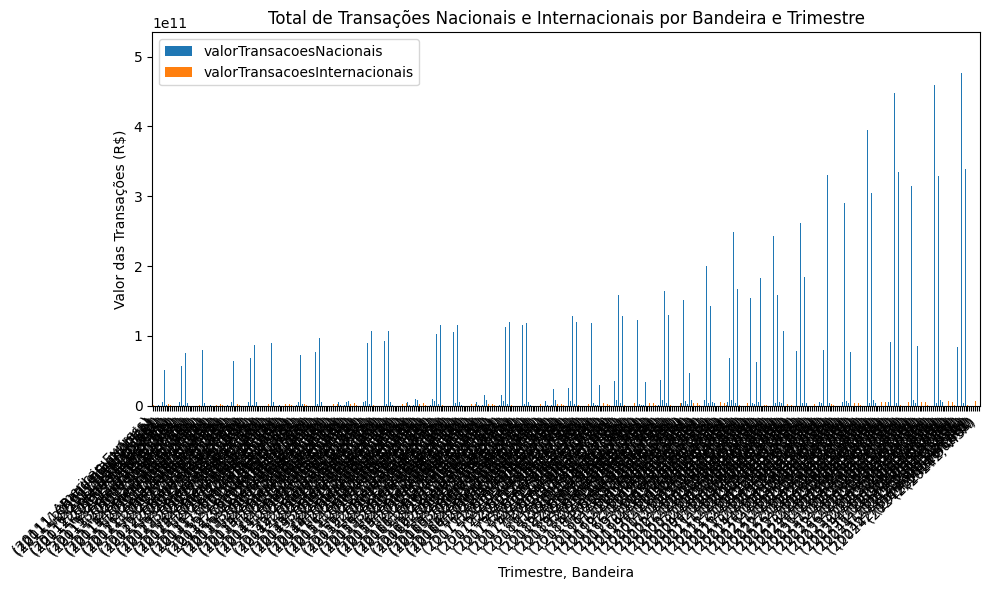

In [ ]:
import matplotlib.pyplot as plt

df_grouped = transacaoCartao.groupby(['trimestre', 'nomeBandeira'])[['valorTransacoesNacionais', 'valorTransacoesInternacionais']].sum()

df_grouped.plot(kind='bar', figsize=(10, 6))

plt.title('Total de Transações Nacionais e Internacionais por Bandeira e Trimestre')
plt.ylabel('Valor das Transações (R$)')
plt.xlabel('Trimestre, Bandeira')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

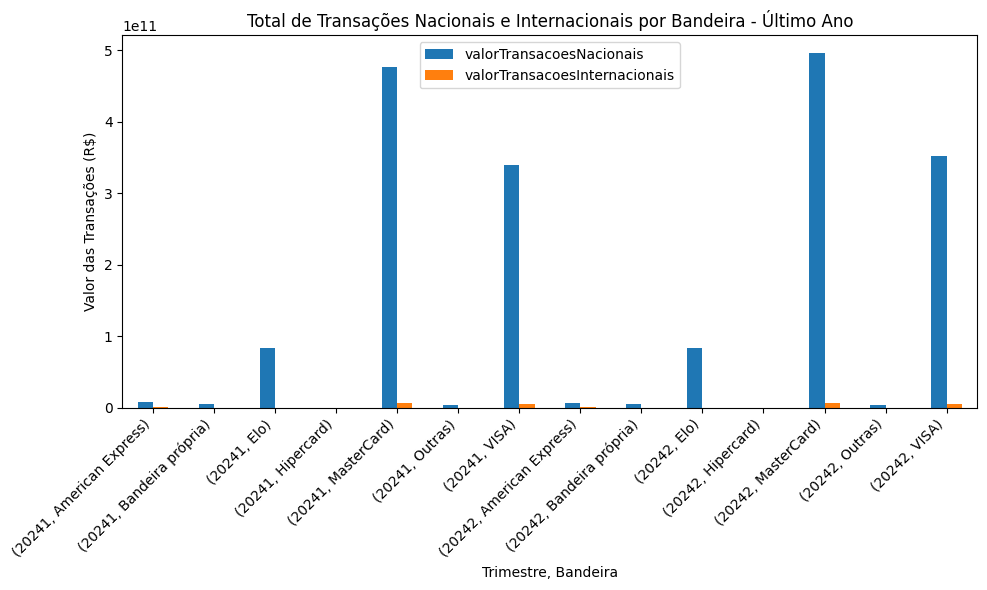

In [ ]:
transacaoCartao['trimestre'] = transacaoCartao['trimestre'].astype(int)

df_last_year = transacaoCartao[transacaoCartao['trimestre'] >= 20240]

df_last_year_grouped = df_last_year.groupby(['trimestre', 'nomeBandeira'])[['valorTransacoesNacionais', 'valorTransacoesInternacionais']].sum()

df_last_year_grouped.plot(kind='bar', figsize=(10, 6))

plt.title('Total de Transações Nacionais e Internacionais por Bandeira - Último Ano')
plt.ylabel('Valor das Transações (R$)')
plt.xlabel('Trimestre, Bandeira')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

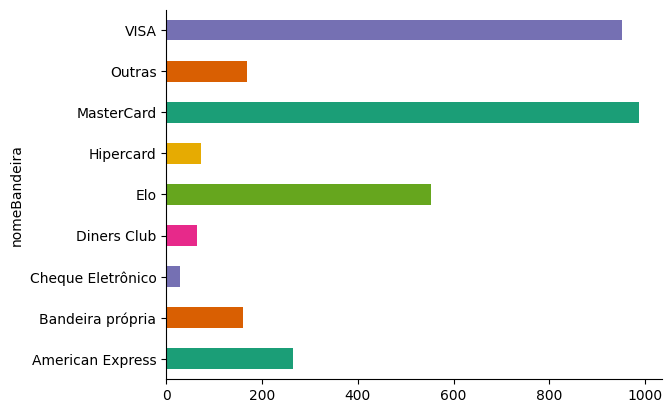

In [ ]:
# @title nomeBandeira

from matplotlib import pyplot as plt
import seaborn as sns
transacaoCartao.groupby('nomeBandeira').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

## Consumo API IBGE

### Como Resolvemos em sala

In [ ]:
# PMS 8688 Total
urlibge1 = 'https://servicodados.ibge.gov.br/api/v3/agregados/8688/periodos/202001-202407/variaveis/11623?localidades=N1[all]&classificacao=11046[56726]|12355[107071]'

In [ ]:
import pandas as pd

data = pd.read_json(urlibge1)

df = pd.json_normalize(data['resultados'][0][0])

import pandas as pd

data = pd.read_json(url2)

df = data['resultados'][0]

pms = df[0]['series'][0]['serie']


em PMS temos um dicionário , mas queremos que a chave seja uma data (atualmente temos '202001') e os valores sejam números (atualmente temos '0.3')

In [ ]:
df['series'][0][0]['serie'].values()

dict_values(['0.6', '0.2', '-9.0', '-11.0', '-1.1', '4.4', '2.6', '3.1', '3.0', '2.4', '1.5', '0.3', '1.6', '2.8', '-4.8', '2.6', '2.0', '2.5', '0.6', '0.5', '-0.6', '-0.6', '2.7', '2.3', '-1.1', '0.4', '0.6', '0.5', '0.6', '0.4', '1.1', '1.6', '0.8', '-0.2', '-0.4', '2.6', '-3.8', '1.3', '1.3', '-1.8', '1.7', '-0.1', '0.5', '-0.3', '-0.2', '-0.4', '1.0', '0.4', '0.5', '-0.4', '0.3', '0.2', '-0.4', '1.4', '0.2'])

In [ ]:
url3 = 'https://servicodados.ibge.gov.br/api/v3/agregados/8693/periodos/202001-202407/variaveis/11623?localidades=N3[all]&classificacao=11046[56726]|12355[107071]'


In [ ]:
data = pd.read_json(url3)
pms = data['resultados'][0][0]['series'][0]['serie']

In [ ]:
df1 = pd.json_normalize(data['resultados'][0][0])

In [ ]:
def teste(i):
  print(df1['series'][0][i]['localidade']['nome'])
  print(df1['series'][0][i]['serie'])

In [ ]:
teste(0)

Ceará
{'202001': '2.5', '202002': '-0.9', '202003': '-5.5', '202004': '-20.2', '202005': '0.3', '202006': '4.7', '202007': '-4.1', '202008': '8.9', '202009': '4.3', '202010': '2.8', '202011': '1.3', '202012': '0.9', '202101': '0.7', '202102': '2.2', '202103': '-2.1', '202104': '-0.2', '202105': '2.8', '202106': '2.0', '202107': '3.3', '202108': '3.1', '202109': '-1.0', '202110': '7.8', '202111': '-1.0', '202112': '-3.3', '202201': '0.7', '202202': '-0.9', '202203': '3.9', '202204': '1.1', '202205': '5.4', '202206': '-5.9', '202207': '-2.4', '202208': '1.9', '202209': '0.2', '202210': '-0.4', '202211': '1.2', '202212': '3.9', '202301': '-4.2', '202302': '2.7', '202303': '3.4', '202304': '-0.2', '202305': '0.0', '202306': '-5.0', '202307': '6.0', '202308': '-3.3', '202309': '2.0', '202310': '-2.1', '202311': '-1.4', '202312': '1.0', '202401': '2.4', '202402': '-1.6', '202403': '-1.9', '202404': '2.3', '202405': '0.2', '202406': '1.6', '202407': '-0.2'}


### PMS Vendas - Brasil

como fui investigando o json

In [ ]:
import pandas as pd

url ='https://servicodados.ibge.gov.br/api/v3/agregados/8688/periodos/201101-202407/variaveis/11623?localidades=N1[all]&classificacao=11046[56726]|12355[107071,106869,106874,31399,106876,31426]'
data = pd.read_json(url)

df = pd.json_normalize(data['resultados'][0])

for i in range(len(df['classificacoes'])):
    print(df['classificacoes'][i][1]['categoria'].values()) # nome da coluna
    print(df['series'][i][0]['serie']) # valores da coluna

dict_values(['Total'])
{'201101': '...', '201102': '0.1', '201103': '-0.3', '201104': '0.8', '201105': '0.5', '201106': '0.0', '201107': '1.5', '201108': '-0.3', '201109': '-0.1', '201110': '-1.2', '201111': '1.6', '201112': '1.3', '201201': '-0.5', '201202': '1.1', '201203': '0.2', '201204': '-1.1', '201205': '1.5', '201206': '0.6', '201207': '-0.3', '201208': '1.2', '201209': '-0.3', '201210': '0.4', '201211': '0.1', '201212': '1.6', '201301': '-1.0', '201302': '0.6', '201303': '0.2', '201304': '1.1', '201305': '-0.2', '201306': '1.1', '201307': '-0.2', '201308': '-0.4', '201309': '0.7', '201310': '0.6', '201311': '1.0', '201312': '-0.3', '201401': '0.8', '201402': '-0.6', '201403': '0.2', '201404': '0.2', '201405': '-0.1', '201406': '-0.9', '201407': '0.8', '201408': '-0.2', '201409': '0.7', '201410': '0.4', '201411': '0.6', '201412': '-2.0', '201501': '-1.6', '201502': '0.6', '201503': '0.6', '201504': '-1.6', '201505': '0.2', '201506': '-1.4', '201507': '-0.7', '201508': '0.7', '2

Passando um prompt para o IA:

criar um dataframe onde

df = pd.json_normalize(data['resultados'][0])

for i in range(len(df['classificacoes'])):
    print(df['classificacoes'][i][1]['categoria'].values()) -> nome da coluna
    print(df['series'][i][0]['serie']) -> valores da coluna

**Resultado:**

In [ ]:
import os

# Diretório onde o arquivo será salvo
directory = "datasets"

# Verifica se o diretório já existe, caso contrário, cria o diretório
if not os.path.exists(directory):
    os.makedirs(directory)

url ='https://servicodados.ibge.gov.br/api/v3/agregados/8688/periodos/201101-202407/variaveis/11623?localidades=N1[all]&classificacao=11046[56726]|12355[107071,106869,106874,31399,106876,31426]'
data = pd.read_json(url)

# Normalizar o JSON para um DataFrame
df = pd.json_normalize(data['resultados'][0])

# Criar um dicionário para armazenar as séries temporais com seus respectivos nomes de coluna
series_dict = {}

# Iterar sobre as classificações e séries
for i in range(len(df['classificacoes'])):
    # Extrair o nome da coluna
    nome_coluna = list(df['classificacoes'][i][1]['categoria'].values())[0]

    # Extrair os valores da série
    serie_valores = df['series'][i][0]['serie']

    # Adicionar a série ao dicionário
    series_dict[nome_coluna] = serie_valores

# Criar um DataFrame a partir do dicionário de séries
df_series = pd.DataFrame(series_dict)

# Adicionar a coluna de Data como índice (anos-meses)
df_series.index = df['series'][0][0]['serie'].keys()

# Certificar que o índice está no formato datetime para posterior análise
df_series.index = pd.to_datetime(df_series.index, format='%Y%m')

# Renomear o índice para "Data"
df_series.index.name = "Data"

# Exibir o DataFrame criado
display(df_series)

# Salvar o DataFrame em um CSV com a formatação brasileira
df_series.to_csv('datasets/pms_vendas.csv', sep=';', encoding='utf-8-sig')

,Total,1. Serviços prestados às famílias,2. Serviços de informação e comunicação,"3. Serviços profissionais, administrativos e complementares","4. Transportes, serviços auxiliares aos transportes e correio",5. Outros serviços
Data,,,,,,
2011-01-01,...,...,...,...,...,...
2011-02-01,0.1,0.5,1.3,1.1,0.0,-0.6
2011-03-01,-0.3,0.5,-1.0,0.2,-2.0,0.1
2011-04-01,0.8,3.1,1.7,0.3,0.7,-1.6
2011-05-01,0.5,-1.6,-0.2,0.8,0.6,2.9
...,...,...,...,...,...,...
2024-03-01,0.3,0.6,4.7,3.3,0.5,-0.1
2024-04-01,0.2,-3.4,0.3,-1.9,1.8,2.7
2024-05-01,-0.4,3.2,-0.9,-0.4,-1.5,-2.2


### PMS Vendas - Estados

In [ ]:
url2 = 'https://servicodados.ibge.gov.br/api/v3/agregados/8693/periodos/201101-202407/variaveis/11623?localidades=N3[all]&classificacao=11046[56726]|12355[all]'
data2 = pd.read_json(url2)

df2 = pd.json_normalize(data2['resultados'][0])
print(df2['classificacoes'][0][1]['categoria'].values())
for j in range(len(df2['series'][0])):
    print(df2['series'][0][j]['localidade']['nome'])
    print(df2['series'][0][j]['serie'])

dict_values(['Total'])
Ceará
{'201101': '...', '201102': '-5.4', '201103': '2.0', '201104': '-1.4', '201105': '0.5', '201106': '-0.5', '201107': '2.1', '201108': '0.3', '201109': '0.3', '201110': '-0.3', '201111': '2.4', '201112': '0.8', '201201': '1.4', '201202': '-0.8', '201203': '5.8', '201204': '-5.8', '201205': '0.2', '201206': '2.3', '201207': '1.5', '201208': '1.0', '201209': '0.9', '201210': '0.3', '201211': '-2.1', '201212': '6.2', '201301': '-5.1', '201302': '4.9', '201303': '-2.1', '201304': '4.7', '201305': '-1.3', '201306': '1.1', '201307': '3.9', '201308': '-5.2', '201309': '-1.3', '201310': '1.7', '201311': '-0.8', '201312': '0.5', '201401': '-1.8', '201402': '6.6', '201403': '-2.3', '201404': '-0.9', '201405': '1.9', '201406': '-1.4', '201407': '-1.1', '201408': '0.9', '201409': '1.5', '201410': '4.4', '201411': '-2.6', '201412': '2.2', '201501': '-8.6', '201502': '3.1', '201503': '-2.2', '201504': '1.1', '201505': '-0.9', '201506': '0.1', '201507': '-1.3', '201508': '1

In [ ]:
# Carregar os dados da API
url2 = 'https://servicodados.ibge.gov.br/api/v3/agregados/8693/periodos/201101-202407/variaveis/11623?localidades=N3[all]&classificacao=11046[56726]|12355[all]'
data2 = pd.read_json(url2)

# Normalizar o JSON para um DataFrame
df2 = pd.json_normalize(data2['resultados'][0])

# Imprimir as categorias das classificações
print(list(df2['classificacoes'][0][1]['categoria'].values()))

# Dicionário para armazenar os dados extraídos
series_dict2 = {}

# Iterar sobre as séries para extrair as localidades e suas respectivas séries temporais
for j in range(len(df2['series'][0])):
    # Extrair o nome da localidade
    localidade = df2['series'][0][j]['localidade']['nome']

    # Extrair os valores da série para essa localidade
    serie_valores = df2['series'][0][j]['serie']

    # Adicionar a série ao dicionário com o nome da localidade
    series_dict2[localidade] = serie_valores

# Criar um DataFrame com o dicionário de séries
df_series2 = pd.DataFrame(series_dict2)

# Definir a coluna de Data como índice (anos-meses)
df_series2.index = df2['series'][0][0]['serie'].keys()

# Certificar que o índice está no formato datetime para futuras operações
df_series2.index = pd.to_datetime(df_series2.index, format='%Y%m')

# Renomear o índice para "Data"
df_series2.index.name = "Data"

# Exibir o DataFrame
display(df_series2)

# Salvar o DataFrame em um CSV com a formatação brasileira
df_series2.to_csv('datasets/pms_vendas_localidades.csv', sep=';', decimal=',', encoding='utf-8-sig')

['Total']


,Ceará,Pernambuco,Bahia,Minas Gerais,Espírito Santo,Rio de Janeiro,São Paulo,Paraná,Santa Catarina,Rio Grande do Sul,Goiás,Distrito Federal
Data,,,,,,,,,,,,
2011-01-01,...,...,...,...,...,...,...,...,...,...,...,...
2011-02-01,-5.4,-2.8,1.1,0.1,-0.3,0.1,0.1,0.0,0.7,-0.8,0.1,-1.7
2011-03-01,2.0,0.0,-0.7,0.5,1.3,0.5,0.5,-0.6,-2.3,0.4,0.7,-4.3
2011-04-01,-1.4,0.3,-1.0,1.4,2.6,-0.5,2.1,-1.4,0.6,-0.2,1.6,2.4
2011-05-01,0.5,0.4,0.5,0.8,-1.0,1.2,-0.4,0.3,-0.6,1.6,-1.4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-01,-1.9,1.0,0.2,1.1,6.5,1.5,0.9,0.4,0.8,-4.9,0.3,-5.6
2024-04-01,2.3,1.2,2.6,3.2,1.0,-1.5,0.4,-0.7,1.3,0.0,2.0,5.5
2024-05-01,0.2,-0.1,-3.8,-3.5,-0.5,0.2,-0.6,0.2,-2.5,0.1,0.4,-1.9


### PMS Carga - Brasil

In [ ]:
url3 = ' https://servicodados.ibge.gov.br/api/v3/agregados/8695/periodos/201101-202407/variaveis/11623?localidades=N1[all]&classificacao=11046[56726]|12355[56724]'

data3 = pd.read_json(url3)
print(data3['resultados'][0][0]['classificacoes'][1]['categoria'].values())
print(data3['resultados'][0][0]['series'][0]['serie'])

dict_values(['Transporte de cargas'])
{'201101': '...', '201102': '-0.2', '201103': '-0.2', '201104': '0.7', '201105': '1.7', '201106': '-0.4', '201107': '0.1', '201108': '-2.2', '201109': '-0.1', '201110': '-0.2', '201111': '2.6', '201112': '2.4', '201201': '-1.4', '201202': '0.6', '201203': '1.0', '201204': '1.4', '201205': '0.7', '201206': '0.9', '201207': '-2.7', '201208': '7.1', '201209': '0.2', '201210': '1.8', '201211': '-0.3', '201212': '-3.0', '201301': '5.9', '201302': '0.2', '201303': '-0.6', '201304': '2.1', '201305': '-1.5', '201306': '1.5', '201307': '0.1', '201308': '2.2', '201309': '-0.4', '201310': '1.0', '201311': '-1.8', '201312': '-4.9', '201401': '2.1', '201402': '4.2', '201403': '1.6', '201404': '-2.1', '201405': '1.5', '201406': '-3.9', '201407': '2.5', '201408': '-1.6', '201409': '0.8', '201410': '0.8', '201411': '2.4', '201412': '-4.4', '201501': '-2.8', '201502': '-2.5', '201503': '1.2', '201504': '-2.5', '201505': '-1.7', '201506': '-1.0', '201507': '-0.3', '

In [ ]:
# URL da API para Transporte de Cargas
url3 = 'https://servicodados.ibge.gov.br/api/v3/agregados/8695/periodos/201101-202407/variaveis/11623?localidades=N1[all]&classificacao=11046[56726]|12355[56724]'

# Carregar os dados da API
data3 = pd.read_json(url3)

# Extrair as categorias de classificações (exemplo)
classificacao = list(data3['resultados'][0][0]['classificacoes'][1]['categoria'].values())
print("Classificação:", classificacao)

# Extrair a série temporal de Transporte de Cargas
serie_temporal = data3['resultados'][0][0]['series'][0]['serie']
print("Série Temporal:", serie_temporal)

# Converter a série temporal em um DataFrame
df_cargas = pd.DataFrame(list(serie_temporal.items()), columns=['Data', 'Transporte de Cargas'])

# Converter a coluna 'Data' para formato datetime
df_cargas['Data'] = pd.to_datetime(df_cargas['Data'], format='%Y%m')

# Exibir o DataFrame
display(df_cargas)

# Salvar o DataFrame em CSV com formatação brasileira
df_cargas.to_csv('datasets/pms_transporte_de_cargas.csv', sep=';', index=False, encoding='utf-8-sig')

Classificação: ['Transporte de cargas']
Série Temporal: {'201101': '...', '201102': '-0.2', '201103': '-0.2', '201104': '0.7', '201105': '1.7', '201106': '-0.4', '201107': '0.1', '201108': '-2.2', '201109': '-0.1', '201110': '-0.2', '201111': '2.6', '201112': '2.4', '201201': '-1.4', '201202': '0.6', '201203': '1.0', '201204': '1.4', '201205': '0.7', '201206': '0.9', '201207': '-2.7', '201208': '7.1', '201209': '0.2', '201210': '1.8', '201211': '-0.3', '201212': '-3.0', '201301': '5.9', '201302': '0.2', '201303': '-0.6', '201304': '2.1', '201305': '-1.5', '201306': '1.5', '201307': '0.1', '201308': '2.2', '201309': '-0.4', '201310': '1.0', '201311': '-1.8', '201312': '-4.9', '201401': '2.1', '201402': '4.2', '201403': '1.6', '201404': '-2.1', '201405': '1.5', '201406': '-3.9', '201407': '2.5', '201408': '-1.6', '201409': '0.8', '201410': '0.8', '201411': '2.4', '201412': '-4.4', '201501': '-2.8', '201502': '-2.5', '201503': '1.2', '201504': '-2.5', '201505': '-1.7', '201506': '-1.0', '

,Data,Transporte de Cargas
0,2011-01-01,...
1,2011-02-01,-0.2
2,2011-03-01,-0.2
3,2011-04-01,0.7
4,2011-05-01,1.7
...,...,...
158,2024-03-01,-0.1
159,2024-04-01,-0.1
160,2024-05-01,-0.5
161,2024-06-01,0.4
